# Agentic AI Fundamentals

## Notebook 11: Multi-Agent Systems: Delegation, Handoffs, and Coordination

A multi-agent system is useful when a task benefits from genuinely different responsibilities, tools, context, or permission boundaries. It is not automatically better than one capable agent. More agents create more model calls, more state transitions, and more opportunities for information to be lost between roles.

In this notebook, we will build a small research team with a coordinator, a research specialist, a calculation specialist, and a writer. The local version is deterministic and fully inspectable. An optional Gemini section then replaces selected decisions with real model calls while preserving the same contracts.

## Learning objectives

By the end of this notebook, you should be able to:

- decide when multiple agents are justified;
- distinguish delegation from a conversational handoff;
- define narrow contracts between specialist agents;
- coordinate specialists through explicit shared state;
- preserve provenance when one agent uses another agent's result;
- enforce budgets and termination conditions;
- inspect a multi-agent execution trace; and
- integrate real LLM calls without surrendering orchestration control.

## 1. One agent or several?

| Situation | Better starting point |
|---|---|
| One prompt, a few tools, and one permission boundary | Single tool-using agent |
| Predictable ordered steps | Workflow |
| Different tool access or security boundaries | Multiple specialists |
| Large domain-specific contexts that should remain isolated | Multiple specialists |
| Different quality criteria, such as research and editorial review | Multiple specialists |
| “It sounds impressive” | Not a sufficient reason |

Start with the smallest architecture that satisfies the requirements. A multi-agent design earns its complexity only when specialization, isolation, or independent review produces measurable value.

## 2. Delegation and handoff are different patterns

**Delegation** means that a coordinator remains responsible for the task. It sends a bounded subtask to a specialist, receives a result, and decides what happens next.

**Handoff** transfers responsibility. The receiving agent becomes the active owner of the conversation or workflow until it completes the request or hands control elsewhere.

We will implement delegation first because its central control flow is easier to trace, budget, and evaluate. A later section will model a true conversational handoff.

## 3. Install dependencies

The main graph runs locally with LangGraph and Pydantic. Gemini is required only for the optional live-team section.

In [ ]:
%pip install -q -U "langgraph>=1.0,<2" "google-genai>=1.0.0" "pydantic>=2.7,<3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 14.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.1 which is incompatible.


In [ ]:
import ast
import json
import operator
import re
import time
from dataclasses import asdict, dataclass
from typing import Any, Literal, TypedDict

from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, ConfigDict, Field, ValidationError

## 4. Define contracts before prompts

Agent names such as “researcher” and “writer” are only labels. Reliability comes from the contract: what input a specialist receives, what output it must return, what tools it may access, and what it must not do.

Pydantic models make those boundaries concrete. The coordinator can reject a malformed result instead of quietly passing ambiguous text to the next agent.

In [ ]:
class ResearchRequest(BaseModel):
    model_config = ConfigDict(extra="forbid")
    query: str = Field(min_length=3, max_length=500)
    max_sources: int = Field(default=3, ge=1, le=5)


class SourceFinding(BaseModel):
    model_config = ConfigDict(extra="forbid")
    source_id: str
    claim: str
    value: float | None = None
    unit: str | None = None


class ResearchReport(BaseModel):
    model_config = ConfigDict(extra="forbid")
    query: str
    findings: list[SourceFinding]
    limitations: list[str] = Field(default_factory=list)


class CalculationRequest(BaseModel):
    model_config = ConfigDict(extra="forbid")
    expression: str = Field(min_length=1, max_length=100)
    purpose: str = Field(min_length=3, max_length=300)


class CalculationResult(BaseModel):
    model_config = ConfigDict(extra="forbid")
    expression: str
    result: float
    purpose: str


class WriterRequest(BaseModel):
    model_config = ConfigDict(extra="forbid")
    user_request: str
    research: ResearchReport | None = None
    calculation: CalculationResult | None = None

## 5. Give each specialist the minimum capability it needs

The research specialist can search a small local knowledge base. The calculation specialist can evaluate only arithmetic expressions. The writer receives evidence but cannot call either tool itself.

This separation is useful even when all roles use the same underlying model. It reduces prompt size, limits permissions, and makes failures easier to attribute.

In [ ]:
KNOWLEDGE_BASE = [
    {
        "source_id": "benchmark-2026",
        "text": "The evaluated baseline completes 80 percent of tasks successfully.",
        "tags": {"baseline", "success", "evaluation"},
        "value": 80.0,
        "unit": "percent",
    },
    {
        "source_id": "candidate-2026",
        "text": "The candidate completes 92 percent of tasks successfully.",
        "tags": {"candidate", "success", "evaluation"},
        "value": 92.0,
        "unit": "percent",
    },
    {
        "source_id": "latency-2026",
        "text": "The candidate has a measured p95 latency of 1.4 seconds.",
        "tags": {"candidate", "latency", "evaluation"},
        "value": 1.4,
        "unit": "seconds",
    },
    {
        "source_id": "policy-guide",
        "text": "Release decisions must include safety checks, not only average task success.",
        "tags": {"safety", "release", "evaluation"},
        "value": None,
        "unit": None,
    },
]


def research_specialist(request_data: dict[str, Any]) -> ResearchReport:
    request = ResearchRequest.model_validate(request_data)
    terms = set(re.findall(r"[a-z]+", request.query.lower()))

    ranked = sorted(
        KNOWLEDGE_BASE,
        key=lambda document: len(terms & document["tags"]),
        reverse=True,
    )
    selected = [
        document for document in ranked
        if terms & document["tags"]
    ][: request.max_sources]

    return ResearchReport(
        query=request.query,
        findings=[
            SourceFinding(
                source_id=document["source_id"],
                claim=document["text"],
                value=document["value"],
                unit=document["unit"],
            )
            for document in selected
        ],
        limitations=[] if selected else ["No matching local evidence was found."],
    )

In [ ]:
BINARY_OPERATORS = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
}


def evaluate_arithmetic(expression: str) -> float:
    tree = ast.parse(expression, mode="eval")

    def visit(node: ast.AST) -> float:
        if isinstance(node, ast.Expression):
            return visit(node.body)
        if isinstance(node, ast.Constant) and type(node.value) in (int, float):
            return float(node.value)
        if isinstance(node, ast.UnaryOp) and isinstance(node.op, ast.USub):
            return -visit(node.operand)
        if isinstance(node, ast.BinOp) and type(node.op) in BINARY_OPERATORS:
            return BINARY_OPERATORS[type(node.op)](visit(node.left), visit(node.right))
        raise ValueError("Only basic arithmetic is allowed.")

    return visit(tree)


def calculation_specialist(request_data: dict[str, Any]) -> CalculationResult:
    request = CalculationRequest.model_validate(request_data)
    return CalculationResult(
        expression=request.expression,
        result=evaluate_arithmetic(request.expression),
        purpose=request.purpose,
    )

In [ ]:
def writing_specialist(request_data: dict[str, Any]) -> str:
    request = WriterRequest.model_validate(request_data)
    evidence = request.research.findings if request.research else []
    source_ids = [finding.source_id for finding in evidence]

    baseline = next(
        (finding.value for finding in evidence if finding.source_id == "benchmark-2026"),
        None,
    )
    candidate = next(
        (finding.value for finding in evidence if finding.source_id == "candidate-2026"),
        None,
    )

    if baseline is not None and candidate is not None and request.calculation:
        return (
            f"The candidate improves task success from {baseline:g}% to "
            f"{candidate:g}%, an increase of {request.calculation.result:g} "
            f"percentage points. This supports further release review, but the "
            f"safety gate must still pass. Sources: {', '.join(source_ids)}."
        )

    if evidence:
        claims = " ".join(finding.claim for finding in evidence)
        return f"{claims} Sources: {', '.join(source_ids)}."

    return "The team could not find enough evidence to answer confidently."

## 6. Define shared state and an audit trail

Shared state should contain durable facts about the run, not the private scratchpad of every role. We keep the original request, validated specialist outputs, a final answer, an explicit next step, a step budget, and trace events.

The trace records what was delegated and returned. It does not expose hidden chain-of-thought.

In [ ]:
class TeamState(TypedDict, total=False):
    user_request: str
    research_query: str
    research_report: dict[str, Any]
    calculation_request: dict[str, Any]
    calculation_result: dict[str, Any]
    final_answer: str
    next_agent: Literal["researcher", "calculator", "writer", "finish"]
    step_count: int
    max_steps: int
    status: Literal["running", "completed", "budget_exceeded", "failed"]
    trace: list[dict[str, Any]]


def add_event(state: TeamState, event: str, **data: Any) -> list[dict[str, Any]]:
    return state.get("trace", []) + [
        {
            "step": state.get("step_count", 0),
            "event": event,
            **data,
        }
    ]

## 7. Make the coordinator explicit

The coordinator does not solve specialist tasks. It plans, validates what is available, and chooses the next role. Our demonstration request needs research first, then a calculation using the retrieved values, and finally writing.

Every node increments the step counter. If the budget is exhausted, routing stops before another specialist is called.

In [ ]:
def coordinator_node(state: TeamState) -> dict[str, Any]:
    step_count = state.get("step_count", 0) + 1
    max_steps = state.get("max_steps", 6)

    if step_count > max_steps:
        return {
            "step_count": step_count,
            "next_agent": "finish",
            "status": "budget_exceeded",
            "trace": add_event(
                state, "budget_exceeded", step=step_count, max_steps=max_steps
            ),
        }

    if "research_report" not in state:
        next_agent = "researcher"
    elif "calculation_result" not in state:
        next_agent = "calculator"
    elif "final_answer" not in state:
        next_agent = "writer"
    else:
        next_agent = "finish"

    return {
        "step_count": step_count,
        "next_agent": next_agent,
        "status": "completed" if next_agent == "finish" else "running",
        "trace": add_event(
            state,
            "coordination_decision",
            step=step_count,
            next_agent=next_agent,
        ),
    }

In [ ]:
def researcher_node(state: TeamState) -> dict[str, Any]:
    request = {
        "query": state.get("research_query", state["user_request"]),
        "max_sources": 4,
    }
    report = research_specialist(request)
    return {
        "research_report": report.model_dump(),
        "trace": add_event(
            state,
            "delegation_completed",
            agent="researcher",
            sources=[finding.source_id for finding in report.findings],
        ),
    }


def calculator_node(state: TeamState) -> dict[str, Any]:
    report = ResearchReport.model_validate(state["research_report"])
    values = {
        finding.source_id: finding.value
        for finding in report.findings
        if finding.value is not None
    }

    if "benchmark-2026" not in values or "candidate-2026" not in values:
        raise ValueError("Required benchmark values were not retrieved.")

    request = CalculationRequest(
        expression=f"{values['candidate-2026']} - {values['benchmark-2026']}",
        purpose="Calculate the candidate's absolute improvement in percentage points.",
    )
    result = calculation_specialist(request.model_dump())
    return {
        "calculation_request": request.model_dump(),
        "calculation_result": result.model_dump(),
        "trace": add_event(
            state,
            "delegation_completed",
            agent="calculator",
            expression=result.expression,
            result=result.result,
        ),
    }


def writer_node(state: TeamState) -> dict[str, Any]:
    request = WriterRequest(
        user_request=state["user_request"],
        research=ResearchReport.model_validate(state["research_report"]),
        calculation=CalculationResult.model_validate(state["calculation_result"]),
    )
    answer = writing_specialist(request.model_dump())
    return {
        "final_answer": answer,
        "trace": add_event(state, "delegation_completed", agent="writer"),
    }

## 8. Assemble the LangGraph team


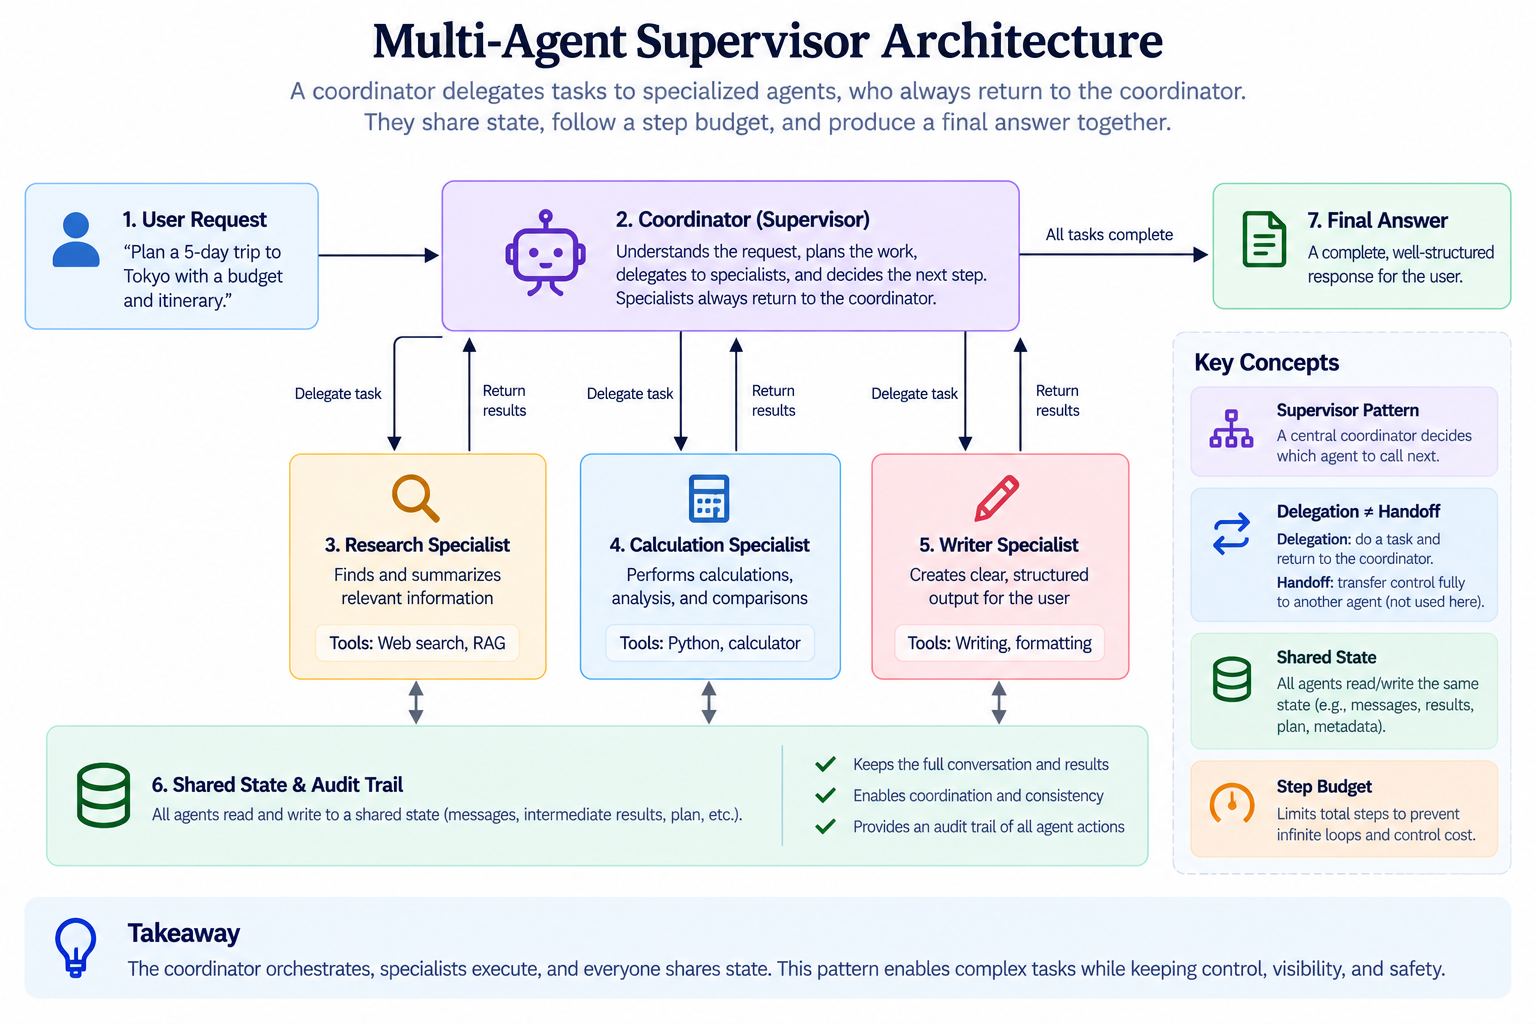

The coordinator is the only component that chooses the next agent. Specialists always return to it. This supervisor pattern trades some extra calls for a clear control point.

In [ ]:
def route_from_coordinator(state: TeamState) -> str:
    return state["next_agent"]


team_builder = StateGraph(TeamState)
team_builder.add_node("coordinator", coordinator_node)
team_builder.add_node("researcher", researcher_node)
team_builder.add_node("calculator", calculator_node)
team_builder.add_node("writer", writer_node)

team_builder.add_edge(START, "coordinator")
team_builder.add_conditional_edges(
    "coordinator",
    route_from_coordinator,
    {
        "researcher": "researcher",
        "calculator": "calculator",
        "writer": "writer",
        "finish": END,
    },
)
team_builder.add_edge("researcher", "coordinator")
team_builder.add_edge("calculator", "coordinator")
team_builder.add_edge("writer", "coordinator")

team_graph = team_builder.compile()

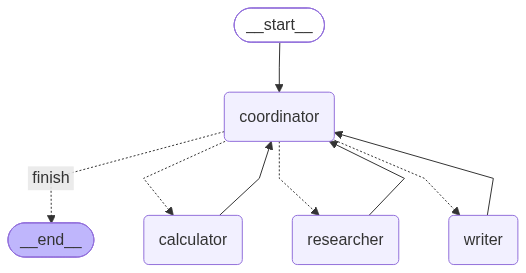

In [ ]:
from IPython.display import Image, display

display(Image(team_graph.get_graph().draw_mermaid_png()))

In [ ]:
initial_state: TeamState = {
    "user_request": (
        "Compare the baseline and candidate task-success rates, calculate "
        "the absolute improvement, and write a short release note."
    ),
    "research_query": "baseline candidate success safety evaluation",
    "step_count": 0,
    "max_steps": 6,
    "status": "running",
    "trace": [],
}

team_result = team_graph.invoke(initial_state)
print(team_result["final_answer"])
print("Status:", team_result["status"])
print("Coordinator steps:", team_result["step_count"])

The candidate improves task success from 80% to 92%, an increase of 12 percentage points. This supports further release review, but the safety gate must still pass. Sources: benchmark-2026, candidate-2026, latency-2026, policy-guide.
Status: completed
Coordinator steps: 4


In [ ]:
print(json.dumps(team_result["trace"], indent=2))

[
  {
    "step": 1,
    "event": "coordination_decision",
    "next_agent": "researcher"
  },
  {
    "step": 1,
    "event": "delegation_completed",
    "agent": "researcher",
    "sources": [
      "benchmark-2026",
      "candidate-2026",
      "latency-2026",
      "policy-guide"
    ]
  },
  {
    "step": 2,
    "event": "coordination_decision",
    "next_agent": "calculator"
  },
  {
    "step": 2,
    "event": "delegation_completed",
    "agent": "calculator",
    "expression": "92.0 - 80.0",
    "result": 12.0
  },
  {
    "step": 3,
    "event": "coordination_decision",
    "next_agent": "writer"
  },
  {
    "step": 3,
    "event": "delegation_completed",
    "agent": "writer"
  },
  {
    "step": 4,
    "event": "coordination_decision",
    "next_agent": "finish"
  }
]


The trace lets us answer concrete questions: Which role ran? Which sources were retrieved? Which arithmetic expression was evaluated? Did the system terminate normally? That evidence is more useful than a transcript in which several personas simply agree with one another.

## 9. Test the budget guard

Multi-agent loops need a hard operational limit even when the routing logic appears correct. A prompt change or malformed result can otherwise cause repeated delegation. We intentionally set an insufficient budget and confirm that the graph terminates with an explicit status.

In [ ]:
budget_limited_state = {
    **initial_state,
    "max_steps": 1,
    "trace": [],
}
budget_result = team_graph.invoke(budget_limited_state)

print("Status:", budget_result["status"])
print("Final answer present:", "final_answer" in budget_result)
print(json.dumps(budget_result["trace"], indent=2))

Status: budget_exceeded
Final answer present: False
[
  {
    "step": 1,
    "event": "coordination_decision",
    "next_agent": "researcher"
  },
  {
    "step": 1,
    "event": "delegation_completed",
    "agent": "researcher",
    "sources": [
      "benchmark-2026",
      "candidate-2026",
      "latency-2026",
      "policy-guide"
    ]
  },
  {
    "step": 2,
    "event": "budget_exceeded",
    "max_steps": 1
  }
]


A production budget may include model calls, total tokens, wall-clock time, tool calls, and monetary cost—not only graph steps. Exceeding a budget should produce an observable terminal state rather than an incomplete answer disguised as success.

## 10. Model a true conversational handoff

In a handoff architecture, a router transfers ownership to another agent. The destination must receive the user-visible conversation context and a clear reason for the transfer. It should not receive unrelated internal state.

The following small example routes billing and technical requests to different owners. Unlike our supervisor graph, the router does not expect a subtask result back before replying.

In [ ]:
@dataclass(frozen=True)
class Handoff:
    from_agent: str
    to_agent: str
    reason: str
    user_message: str


def triage_agent(user_message: str) -> Handoff:
    lower = user_message.lower()
    if any(word in lower for word in ("invoice", "charge", "billing")):
        destination = "billing_agent"
        reason = "The request concerns billing records."
    elif any(word in lower for word in ("error", "api", "timeout")):
        destination = "technical_agent"
        reason = "The request requires technical troubleshooting."
    else:
        destination = "general_agent"
        reason = "No specialist category was detected."

    return Handoff(
        from_agent="triage_agent",
        to_agent=destination,
        reason=reason,
        user_message=user_message,
    )


handoff = triage_agent("The API request times out after thirty seconds.")
print(asdict(handoff))

{'from_agent': 'triage_agent', 'to_agent': 'technical_agent', 'reason': 'The request requires technical troubleshooting.', 'user_message': 'The API request times out after thirty seconds.'}


In [ ]:
def technical_agent(handoff: Handoff) -> dict[str, str]:
    if handoff.to_agent != "technical_agent":
        raise ValueError("This handoff was not addressed to the technical agent.")
    return {
        "active_agent": "technical_agent",
        "response": (
            "I will handle the technical investigation. First, confirm whether "
            "the timeout occurs before or after the external tool is called."
        ),
    }


print(technical_agent(handoff))

{'active_agent': 'technical_agent', 'response': 'I will handle the technical investigation. First, confirm whether the timeout occurs before or after the external tool is called.'}


In a real chat system, the active-agent identity should become part of durable conversation state. That prevents every new turn from being sent back through triage and allows an explicit hand-back when the specialist has finished.

## 11. Common multi-agent failure modes

| Failure mode | What it looks like | Practical control |
|---|---|---|
| Role overlap | Several agents repeat the same work | Narrow, non-overlapping contracts |
| Context loss | A specialist receives an incomplete task | Typed handoff payloads |
| Error amplification | Later agents treat an early guess as fact | Provenance and confidence fields |
| Infinite delegation | Agents repeatedly transfer ownership | Step, token, time, and cost budgets |
| Premature synthesis | Writer responds before evidence arrives | State preconditions |
| Permission leakage | A writer can invoke administrative tools | Per-agent tool allowlists |
| Consensus theater | Agents agree without independent evidence | Independent checks and measurable rubrics |

Multi-agent reliability depends less on colorful personas and more on contracts, state, permissions, and termination.

## 12. Optional: replace deterministic specialists with Gemini

A real multi-agent system does not require a special “multi-agent API.” It can be several model calls with different instructions, tools, context, and output schemas, coordinated by application code or a graph.

The following example makes three distinct Gemini calls: a planner creates a structured plan, an analyst interprets trusted local evidence, and a writer produces the final note. The arithmetic remains deterministic Python because an LLM is unnecessary for subtraction.

Add `GEMINI_API_KEY` to Colab Secrets before running these cells.

In [ ]:
import os
from google import genai
from google.genai import types


def load_gemini_api_key() -> str:
    try:
        from google.colab import userdata
        api_key = userdata.get("GEMINI_API_KEY")
    except (ImportError, KeyError):
        api_key = os.getenv("GEMINI_API_KEY")

    if not api_key:
        raise RuntimeError("Add GEMINI_API_KEY to Colab Secrets.")
    return api_key


MODEL_NAME = "gemini-3.8-flash"
client = genai.Client(api_key=load_gemini_api_key())

In [ ]:
class TeamPlan(BaseModel):
    research_question: str
    calculation_needed: bool
    writing_goal: str


live_user_request = (
    "Compare the baseline and candidate task-success rates, calculate the "
    "absolute improvement, and write a cautious release note."
)

planner_response = client.models.generate_content(
    model=MODEL_NAME,
    contents=live_user_request,
    config=types.GenerateContentConfig(
        system_instruction=(
            "You are a coordinator. Create a concise plan for research, "
            "deterministic calculation, and writing. Do not answer the task."
        ),
        response_mime_type="application/json",
        response_schema=TeamPlan,
        temperature=0,
    ),
)
live_plan = TeamPlan.model_validate_json(planner_response.text)
print(live_plan.model_dump())

{'research_question': 'What are the baseline and candidate task-success rates?', 'calculation_needed': True, 'writing_goal': 'Write a cautious release note detailing the performance comparison.'}


In [ ]:
trusted_evidence = research_specialist({
    "query": "baseline candidate success safety evaluation",
    "max_sources": 4,
})

analyst_response = client.models.generate_content(
    model=MODEL_NAME,
    contents=json.dumps(trusted_evidence.model_dump()),
    config=types.GenerateContentConfig(
        system_instruction=(
            "You are an evidence analyst. Identify the baseline rate, candidate "
            "rate, and any release caveat. Use only the supplied evidence and "
            "preserve source IDs. Do not perform the subtraction."
        ),
        temperature=0,
    ),
)

live_calculation = calculation_specialist({
    "expression": "92 - 80",
    "purpose": "Absolute success-rate improvement in percentage points.",
})

print(analyst_response.text)
print(live_calculation.model_dump())

Based on the provided evidence, here are the requested details:

* **Baseline rate:** 80.0 percent (Source: benchmark-2026)
* **Candidate rate:** 92.0 percent (Source: candidate-2026)
* **Release caveat:** Release decisions must include safety checks, not only average task success (Source: policy-guide)
{'expression': '92 - 80', 'result': 12.0, 'purpose': 'Absolute success-rate improvement in percentage points.'}


In [ ]:
writer_payload = {
    "original_request": live_user_request,
    "plan": live_plan.model_dump(),
    "analysis": analyst_response.text,
    "calculation": live_calculation.model_dump(),
}

writer_response = client.models.generate_content(
    model=MODEL_NAME,
    contents=json.dumps(writer_payload),
    config=types.GenerateContentConfig(
        system_instruction=(
            "You are the final writer. Produce a two-sentence release note. "
            "State the improvement in percentage points, preserve source IDs, "
            "and mention the safety caveat. Do not invent evidence."
        ),
        temperature=0,
    ),
)

print(writer_response.text)

The candidate model achieves a task-success rate of 92.0% (Source: candidate-2026) compared to the 80.0% baseline (Source: benchmark-2026), delivering an absolute improvement of 12.0 percentage points. However, because release decisions must include safety checks and not rely solely on average task success (Source: policy-guide), this update should be approached with caution.


These are genuine separate model invocations with different responsibilities, but the application still controls evidence retrieval, arithmetic, state transfer, and termination. That boundary is what turns several prompts into an engineered system.

## 13. Evaluate the team, not only its final prose

Notebook 10's evaluation ideas extend naturally to a team. Useful checks include:

- Was the correct specialist selected?
- Did every handoff satisfy its schema?
- Did the writer use only retrieved source IDs?
- Does the calculated value match deterministic arithmetic?
- Was the step budget respected?
- How many model calls and tokens did the team consume?
- Would a single-agent baseline achieve comparable quality more cheaply?

The last question matters. A multi-agent candidate should be compared with a simpler baseline, not evaluated in isolation.

In [ ]:
def evaluate_team_result(result: TeamState) -> dict[str, Any]:
    trace = result.get("trace", [])
    delegated_agents = [
        event["agent"]
        for event in trace
        if event["event"] == "delegation_completed"
    ]
    answer = result.get("final_answer", "")

    checks = {
        "completed": result.get("status") == "completed",
        "expected_specialists": delegated_agents == [
            "researcher", "calculator", "writer"
        ],
        "correct_calculation": (
            result.get("calculation_result", {}).get("result") == 12.0
        ),
        "provenance_preserved": (
            "benchmark-2026" in answer and "candidate-2026" in answer
        ),
        "budget_respected": result.get("step_count", 0) <= result.get("max_steps", 0),
    }
    return {
        "checks": checks,
        "overall_pass": all(checks.values()),
        "delegated_agents": delegated_agents,
    }


team_evaluation = evaluate_team_result(team_result)
print(json.dumps(team_evaluation, indent=2))

{
  "checks": {
    "completed": true,
    "expected_specialists": true,
    "correct_calculation": true,
    "provenance_preserved": true,
    "budget_respected": true
  },
  "overall_pass": true,
  "delegated_agents": [
    "researcher",
    "calculator",
    "writer"
  ]
}


## 14. Exercise: add an editorial reviewer

Add a reviewer after the writer. The reviewer should not rewrite the answer. It should return a structured result containing:

- `approved: bool`;
- a list of `issues`;
- whether both required source IDs appear; and
- whether the answer mentions the safety caveat.

If the answer is approved, the coordinator may finish. If not, allow exactly one revision before terminating. Use a revision counter so that writer and reviewer cannot loop indefinitely.

In [ ]:
# Define ReviewResult, reviewer_node, and a bounded revision route here.
# Keep the reviewer deterministic first; an LLM reviewer can be added afterward.

<details>
<summary><strong>Implementation guidance</strong></summary>

A clean solution adds `review`, `revision_count`, and `max_revisions` to `TeamState`. The writer routes to the reviewer. The reviewer checks the answer and returns either `approved` or `revise`. On `revise`, increment the counter and route to the writer only when `revision_count < max_revisions`; otherwise terminate with an explicit failure status.

Keep the review result separate from the final answer. This preserves the difference between producing content and deciding whether it meets the release criteria.

</details>

## Notebook summary

We built a supervisor-style multi-agent system whose specialists have narrow contracts and restricted capabilities. LangGraph made the coordination state and routing explicit, while trace events preserved delegation evidence. We then contrasted delegation with a true handoff, added a hard step budget, and implemented an optional live team using separate Gemini calls.

The central lesson is that multi-agent systems are distributed workflows, not merely several personas. Their quality depends on interfaces, provenance, permissions, state ownership, termination, and evaluation.

## Next notebook

**Notebook 12 — MCP Fundamentals: Connecting Agents to External Tools and Resources** will introduce the Model Context Protocol, explain hosts, clients, and servers, and build a small local MCP integration suitable for Colab.